<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_9_Adaptive_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Mean Squared Error (MSE) surfaces, Wiener filters, and the Least Mean Squares (LMS) algorithm.

The Project: Design an Active Noise Cancellation (ANC) system that filters out a constant hum from a voice recording.

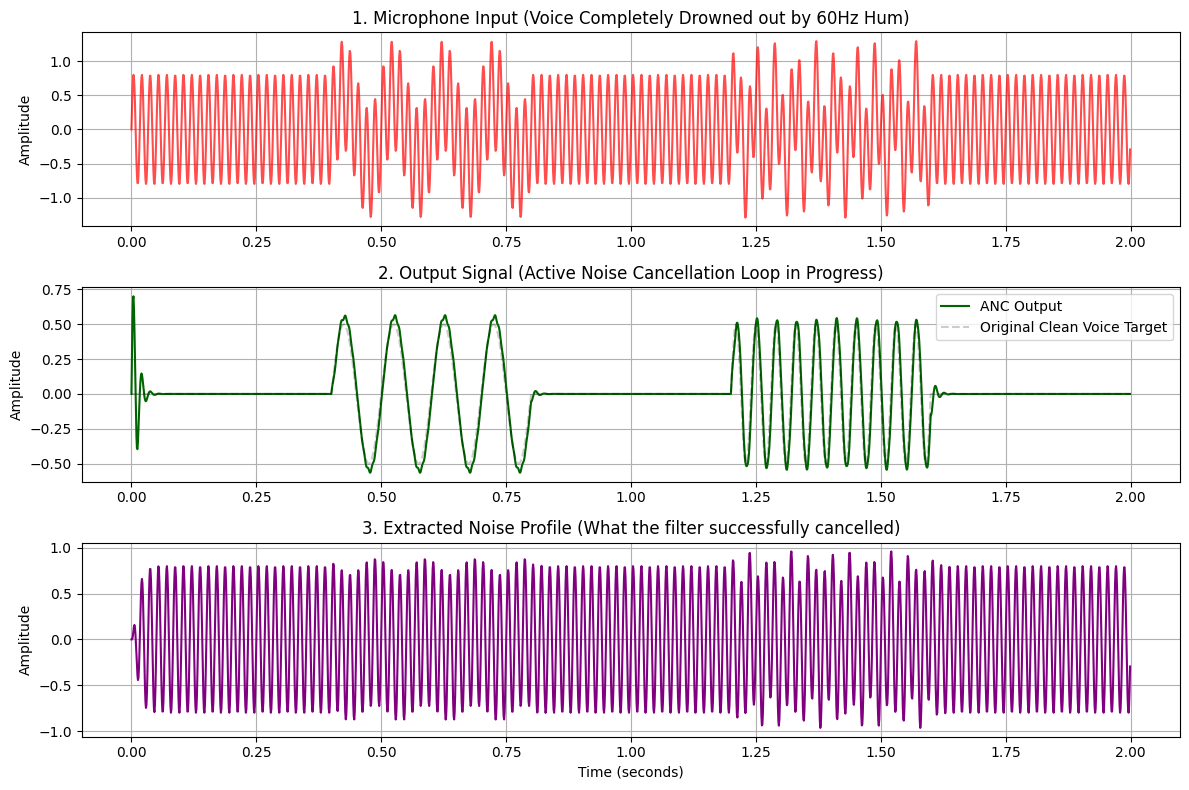

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lms_adaptive_filter(primary, reference, mu=0.01, filter_order=32):
    """
    Applies the Least Mean Squares (LMS) adaptive algorithm to cancel noise.

    Parameters:
        - primary: The corrupted signal array (Signal + Noise).
        - reference: The noise-only reference signal array.
        - mu: Convergence step-size (learning rate).
        - filter_order: Number of filter taps/coefficients.
    """
    N = len(primary)
    w = np.zeros(filter_order)       # Initialize filter weights to zero
    x_buffer = np.zeros(filter_order) # Initialize input delay line buffer

    clean_output = np.zeros(N)

    # Sample-by-sample real-time simulation loop
    for n in range(N):
        # Slide the newest reference sample into our delay line
        x_buffer = np.roll(x_buffer, 1)
        x_buffer[0] = reference[n]

        # Step 1: Predict the noise using current weights
        predicted_noise = np.dot(w, x_buffer)

        # Step 2: Subtract predicted noise from primary signal to get clean audio
        # The residual error 'e' is exactly our cleaned voice signal!
        e = primary[n] - predicted_noise
        clean_output[n] = e

        # Step 3: Update filter weights using the LMS gradient descent step
        w = w + 2 * mu * e * x_buffer

    return clean_output

# --- 1. SYNTHESIZE SIGNALS ---
fs = 1000 # Sampling rate (Hz)
t = np.arange(0, 2, 1/fs) # 2 seconds duration

# Create a mock "Voice" signal that turns on and off
voice = np.zeros_like(t)
voice[400:800] = 0.5 * np.sin(2 * np.pi * 10 * t[400:800])    # Low phrase
voice[1200:1600] = 0.5 * np.sin(2 * np.pi * 25 * t[1200:1600]) # High phrase

# Create the interference (Constant 60 Hz hum)
hum_freq = 60
primary_noise = 0.8 * np.sin(2 * np.pi * hum_freq * t)
# The reference sensor catches the same hum, but with a slight phase shift/distortion
reference_noise = 0.8 * np.sin(2 * np.pi * hum_freq * t + np.pi/4)

# Combine to create the corrupted microphone input
corrupted_audio = voice + primary_noise

# --- 2. RUN THE ANC ENGINE ---
# Run filter with a conservative step size for stability
cleaned_audio = lms_adaptive_filter(corrupted_audio, reference_noise, mu=0.02, filter_order=16)

# --- 3. VISUALIZATION MATRIX ---
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, corrupted_audio, color='red', alpha=0.7)
plt.title("1. Microphone Input (Voice Completely Drowned out by 60Hz Hum)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, cleaned_audio, color='darkgreen', label="ANC Output")
plt.plot(t, voice, color='black', alpha=0.2, linestyle='--', label="Original Clean Voice Target")
plt.title("2. Output Signal (Active Noise Cancellation Loop in Progress)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.subplot(3, 1, 3)
plt.plot(t, corrupted_audio - cleaned_audio, color='purple')
plt.title("3. Extracted Noise Profile (What the filter successfully cancelled)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()